In [1]:
import torch
import cv2
import numpy as np
from scipy.signal import find_peaks
from src.datasets.mos2_sef import MOS2SEFDataset


def calculate_pixel_size(image: np.ndarray, image_size_um: float) -> float:
    """
    Calculate the pixel size in micrometers based on the image dimensions.
    """
    image_width_pixels = image.shape[1]
    pixel_size_um = image_size_um / image_width_pixels
    return pixel_size_um


def process_image(data: np.ndarray, image_size_um: float) -> dict:
    """
    Slightly modified version of a script provided by Md Jayed Hossain at the Celano Lab @ASU.
    
    NOTE: Currently, we struggle to model the outputs of this script.
    - Many opperations are discontinous/non-smooth (e.g., `find_peaks`).
    - Many choices are highly heuristic (e.g., number of bins).
    
    Parameters
    ----------
    data : np.ndarray
        A 2D array representing current values in amperes.
    height : int
        Number of rows in the image (in pixels).
    width : int
        Number of columns in the image (in pixels).
    image_size_um : float
        Size of original_image in micrometers.

    Returns
    -------
    dict
        A dictionary containing the following keys:
        - coverage_percentage (float):
            Range: [0, 1]
            Percentage of the area where the current exceeds a threshold
            determined by the histogram peak.
        - total_len_detected_curves (float):
            Range: [0, inf)
            The total perimeter length (in micrometers) of identified curved lines.
        - total_len_detected_curves_without_boundary (float):
            Range: [0, inf)
            The total perimeter length (in micrometers) of identified curved lines,
            minus the boundary perimeter.
        - total_area_circular_shapes (float):
            Range: [0, inf)
            Combined area (in square micrometers) of detected circular shapes.
        - total_area_extended_shapes (float):
            Range: [0, inf)
            Combined area (in square micrometers) of detected elongated (extended) shapes.
        - total_defect_area (float):
            Range: [0, inf)
            Percentage of the total image area that is covered by detected defects
            (circular and extended shapes).
        - num_circular_shapes (int):
            Range: [0, inf)
            Number of circular shapes identified.
        - num_extended_shapes (int):
            Range: [0, inf)
            Number of extended shapes identified.
        - num_curved_lines (int):
            Range: [0, inf)
            Number of curved lines identified.
        - average_surface_current (float):
            Range: [0, inf)
            Average surface current across the entire image, in nanoamperes.
    """

    # HACK: we always assume BS=1
    # [B, H, W] -> [H, W]
    if len(data.shape) == 2:
        pass
    elif len(data.shape) == 3:
        data = data[0, ...]
    else:
        raise Exception(f"Error: only batch size of one supported for celano-lab evaluation function.")
        
    # -> np.ndarray
    if isinstance(data, torch.Tensor):
        data = data.clone().detach().cpu().numpy()

    height, width = data.shape
    
    # ---- Jayed's script begins ----
    pixel_size_um = calculate_pixel_size(data, image_size_um)

    # NOTE: is this conversion factor huge?
    # Convert the image to picoamperes for better readability
    image_pA = data * 1e12  # Convert from A to pA

    # NOTE: why 10K bins?
    # Calculate the histogram with fine binning
    hist, bin_edges = np.histogram(image_pA.flatten(), bins=10000)

    # HACK: sometimes we don't have a peak height greater or equal to 100
    peak_height = min(100, hist.max() - 1)
    
    # Use `find_peaks` to locate all local maxima in the histogram
    peaks, _ = find_peaks(hist, height=peak_height)  # Adjust `height` to filter insignificant peaks
    peak_intensities = bin_edges[peaks]  # Intensity values corresponding to the peaks

    # Sort the peaks by intensity and filter out the peak at the very beginning (close to 0)
    sorted_peaks = sorted(zip(hist[peaks], peak_intensities), reverse=True)

    # select the primary peak closest to 0
    primary_peak_value = sorted_peaks[0][1]

    # Find the index of the primary peak
    primary_peak_index = np.digitize(
        primary_peak_value, bin_edges
    )  # Find the bin index of the primary peak

    # Previously used purely for debugging
    # Get the next 20 frequencies (counts) in the histogram after the primary peak
    next_frequencies = hist[primary_peak_index + 1 : primary_peak_index + 21]  # Get the next 20 bins

    # Get the corresponding intensity values (bin edges) for those frequencies
    next_intensities = bin_edges[primary_peak_index + 1 : primary_peak_index + 21]

    # Remove values below the primary peak value (set them to 0 or NaN)
    image_pA_filtered = np.copy(image_pA)  # Create a copy of the image
    image_pA_filtered[image_pA_filtered < primary_peak_value] = (
        0  # Set values below primary peak to 0
    )

    # TODO: this breaks... fix!
    # intensity value of the 20th pixel
    intensity_20th_pixel = next_intensities[-1]  # Last value in next_intensities (20th pixel)

    # Calculate the 95th percentile value for clipping
    percentile_96 = np.percentile(data, 96)
    
    # Clip the image at the 95th percentile
    clipped_image = np.clip(data, None, percentile_96)
    
    # Calculate the average current
    average_current = np.mean(data)
    
    # Convert the data to nanoamperes (divide by 10^-9)
    data_nA = average_current / 1e-9
    
    # Normalize data
    normalized_data = cv2.normalize(
        clipped_image, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Define the coverage threshold
    threshold = intensity_20th_pixel * 1e-12

    # Create a binary mask for coverage (1 = covered, 0 = uncovered)
    coverage_mask = (data > threshold).astype(int)
    
    # Calculate coverage percentage
    coverage_percentage = (np.sum(coverage_mask) / coverage_mask.size) * 100

    # Apply Gamma Correction
    gamma = 0.7
    gamma_corrected_img = np.power(normalized_data / 255.0, gamma) * 255.0
    gamma_corrected_img = gamma_corrected_img.astype(np.uint8)

    # Apply Bilateral Filter
    bilateral_filtered = cv2.bilateralFilter(gamma_corrected_img, 9, 30, 75)

    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(bilateral_filtered, (3, 3), 3)

    # Apply Non-Local Means Denoising
    denoised = cv2.fastNlMeansDenoising(blurred, None, 10, 2, 21)

    # Adaptive Thresholding
    thresholded = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 1
    )

    # Contour Detection
    contours, _ = cv2.findContours(thresholded, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    output_image = cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

    curves_length = 0
    circular_shapes_area = 0
    extended_shapes_area = 0
    circular_shapes = []
    curved_lines = []
    extended_shapes = []

    for contour in contours:
        if cv2.contourArea(contour) > 10:
            perimeter = cv2.arcLength(contour, closed=True)
            area = cv2.contourArea(contour)
            circularity = 4 * np.pi * area / (perimeter**2) if perimeter != 0 else 0

            # Create a mask for the contour
            mask = np.zeros_like(thresholded, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 255, -1)

            # Calculate the total number of pixels inside the contour
            total_pixels = cv2.countNonZero(mask)

            # Calculate the number of white pixels inside the contour
            white_pixels = cv2.countNonZero(cv2.bitwise_and(mask, thresholded))

            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = float(w) / h

            if circularity > 0.2 and area <= 1000:
                # Check for white pixel coverage only for circular shapes
                if total_pixels > 0 and (white_pixels / total_pixels) >= 0.8:
                    continue  # Skip this contour if 80% or more of the pixels are white

                # Process circular shapes
                circular_shapes.append(contour)
                circular_shapes_area += area
                cv2.drawContours(output_image, [contour], -1, (0, 255, 255), 1)
            elif aspect_ratio > 1.8 and area <= 1000:
                # Check for white pixel coverage only for extended shapes
                if total_pixels > 0 and (white_pixels / total_pixels) >= 0.8:
                    continue  # Skip this contour if 80% or more of the pixels are white

                # Process extended shapes
                extended_shapes.append(contour)
                extended_shapes_area += area
                cv2.drawContours(output_image, [contour], -1, (0, 255, 255), 1)
            else:
                # Process curved lines without the white pixel check
                curved_lines.append(contour)
                curve_length = cv2.arcLength(contour, closed=True)
                curves_length += curve_length
                cv2.drawContours(output_image, [contour], -1, (0, 255, 0), 1)

    # Convert areas and lengths to micrometers
    circular_shapes_area_um2 = circular_shapes_area * (pixel_size_um**2)
    extended_shapes_area_um2 = extended_shapes_area * (pixel_size_um**2)
    curves_length_um = curves_length * pixel_size_um

    curves_length_um_without_boundary = curves_length_um - (2*(height+width))
    Total_Defect_Area = circular_shapes_area_um2 + extended_shapes_area_um2
    Total_Defect_Percentage = 100 * Total_Defect_Area/ (height*width)
    
    # NOTE: we remove `curves_length_um_without_boundary`, as this metric is consistently negative
    # TODO: normalize all values to a "reasonable" range
    return {
        # "total_len_detected_curves_without_boundary": curves_length_um_without_boundary,
        "coverage_percentage": coverage_percentage,
        "total_len_detected_curves": curves_length_um,
        "total_area_circular_shapes": circular_shapes_area_um2,
        "total_area_extended_shapes": extended_shapes_area_um2,
        "total_defect_area": Total_Defect_Percentage,
        "num_circular_shapes": len(circular_shapes),
        "num_extended_shapes": len(extended_shapes),
        "num_curved_lines": len(curved_lines),
        "average_surface_current": data_nA,
    }
    

In [2]:
from src.datasets.mos2_sef import Formulation as F
dataset = MOS2SEFDataset(formulation=F.P_Y_BAR_Y_SPARSE)

In [3]:
y_sample = dataset[0]['y_unnorm']
y_sample.max(), y_sample.min(), y_sample.mean()

(tensor(2.5080e-08), tensor(2.0266e-11), tensor(8.5884e-09))

In [4]:
sum(y_sample.ravel() < 0), len(y_sample.ravel())

(tensor(0), 16384)

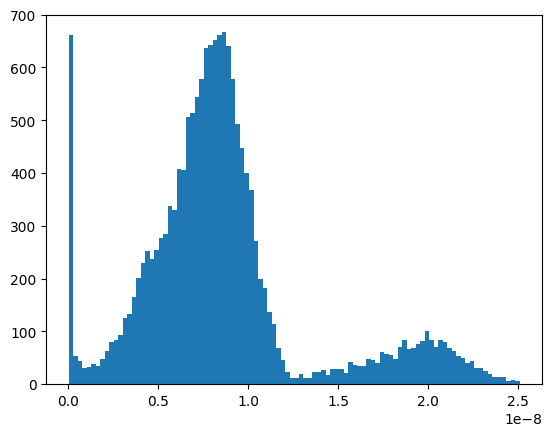

In [5]:
import matplotlib.pyplot as plt
plt.hist(y_sample.ravel(), bins=100);